# Simulation speed

PyKappa simulates Kappa models directly in Python. This benchmark compares it
with compiled simulation using [KaSim](https://github.com/Kappa-Dev/KappaTools).
The measurements are from a local run generated by this
[script](https://github.com/berkalpay/pykappa/blob/main/docs/simulation_speed.py).

Each system starts with `n` agents per species and runs for 1,000 events.
Heterodimerization forms and breaks independent A:B pairs, tiling lets one
agent type form connected two-dimensional structures, and cyclization joins
the ends of linear chains and includes a distinction between unimolecular
and bimolecular rate.

```
// Heterodimerization
A(x[.]), B(x[.]) <-> A(x[1]), B(x[1]) @ 1, 1

// Tiling
A(l[.]), A(r[.]) <-> A(l[1]), A(r[1]) @ 1, 1
A(u[.]), A(d[.]) <-> A(u[1]), A(d[1]) @ 1, 1

// Cyclization
A(r[.]), A(l[.]) <-> A(r[1]), A(l[1]) @ 1 {1}, 1
```

Now we will plot the (precomputed) simulation speeds of these models.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

data = pd.read_csv("simulation_speed.csv")

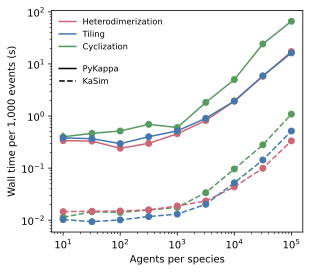

In [2]:
colors = {
    "Heterodimerization": "#cc6677",
    "Tiling": "#4477aa",
    "Cyclization": "#589960",
}
styles = {"PyKappa": "-", "KaSim": "--"}

fig, ax = plt.subplots(figsize=(4.5, 4))
for (engine, ruleset), points in data.groupby(["engine", "ruleset"]):
    ax.errorbar(
        points.agents_per_species,
        points.mean_wall_time_s,
        yerr=points.std_wall_time_s / points.n_runs**0.5,
        color=colors[ruleset],
        linestyle=styles[engine],
        marker="o",
    )

ruleset_legend = ax.legend(
    handles=[
        Line2D([0], [0], color=color, label=ruleset)
        for ruleset, color in colors.items()
    ],
    loc="upper left",
    frameon=False,
    fontsize="small",
)
ax.add_artist(ruleset_legend)
fig.canvas.draw()
legend_box = ruleset_legend.get_window_extent(fig.canvas.get_renderer()).transformed(
    ax.transAxes.inverted()
)
ax.legend(
    handles=[
        Line2D([0], [0], color="black", linestyle=style, label=engine)
        for engine, style in styles.items()
    ],
    frameon=False,
    fontsize="small",
    loc="upper left",
    bbox_to_anchor=(0, legend_box.y0),
    bbox_transform=ax.transAxes,
)
ax.set(
    xscale="log",
    yscale="log",
    xlabel="Agents per species",
    ylabel="Wall time per 1,000 events (s)",
)
plt.show()

Each point is the mean of ten runs. This plot is meant to show scaling trends;
actual wall time depends on the computer.